In [1]:
import pandas as pd

df = pd.read_csv("02_oxide.csv")

df

,process_date,process_time,equipment_id,chamber_id,wafer_id,wafer_doping_type,precleaning_time,oxidation_temperature,oxidation_time,pressure,gas_flow_rate,oxide_thickness,uniformity,defect_count,defect_type
0,2025-01-01,0:00:00,eq_1,chamber_1,w_0,p-type,3,908.332942,30.450712,0.725458,4007.192654,212.318551,4.158928,0,none
1,2025-01-01,1:00:00,eq_2,chamber_2,w_1,n-type,1,998.595807,43.926035,0.610652,3273.074465,359.152236,3.920767,2,particle
2,2025-01-01,2:00:00,eq_3,chamber_3,w_2,p-type,5,1016.761934,66.715328,0.816619,2098.663479,442.100760,2.428848,1,pinhole
3,2025-01-01,3:00:00,eq_4,chamber_1,w_3,n-type,3,952.625393,46.845448,0.761523,2897.739657,225.153908,0.437444,2,particle
4,2025-01-01,4:00:00,eq_5,chamber_2,w_4,p-type,3,968.690498,52.487699,0.649097,2335.106388,423.234943,2.860362,0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-02-11,11:00:00,eq_1,chamber_3,w_995,n-type,4,1068.991935,52.783496,0.302645,4802.014246,464.065417,4.914362,0,none
996,2025-02-11,12:00:00,eq_2,chamber_1,w_996,p-type,5,976.739157,55.965298,0.696086,2534.436161,261.114871,3.471068,0,none
997,2025-02-11,13:00:00,eq_3,chamber_2,w_997,n-type,3,985.560235,45.612643,0.648714,2697.488104,310.582879,0.294383,0,none
998,2025-02-11,14:00:00,eq_4,chamber_3,w_998,p-type,2,946.535657,6.432315,0.923589,3858.784356,179.629674,2.242628,4,particle


In [2]:
columns_names = df.columns
print(columns_names)

Index(['process_date', 'process_time', 'equipment_id', 'chamber_id',
       'wafer_id', 'wafer_doping_type', 'precleaning_time',
       'oxidation_temperature', 'oxidation_time', 'pressure', 'gas_flow_rate',
       'oxide_thickness', 'uniformity', 'defect_count', 'defect_type'],
      dtype='object')


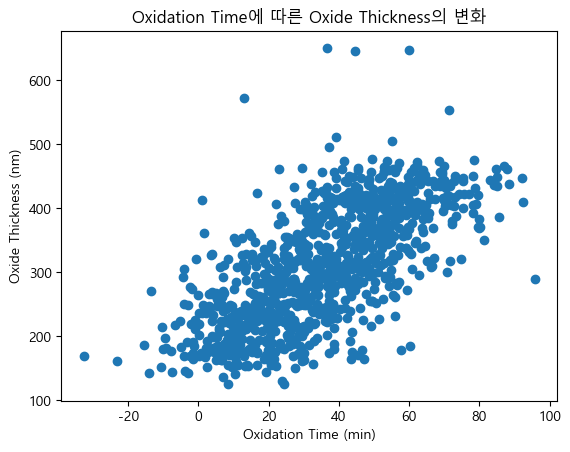

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(df['oxidation_time'], df['oxide_thickness'])
plt.xlabel('Oxidation Time (min)')
plt.ylabel('Oxide Thickness (nm)')
plt.title("Oxidation Time에 따른 Oxide Thickness의 변화")
plt.show()

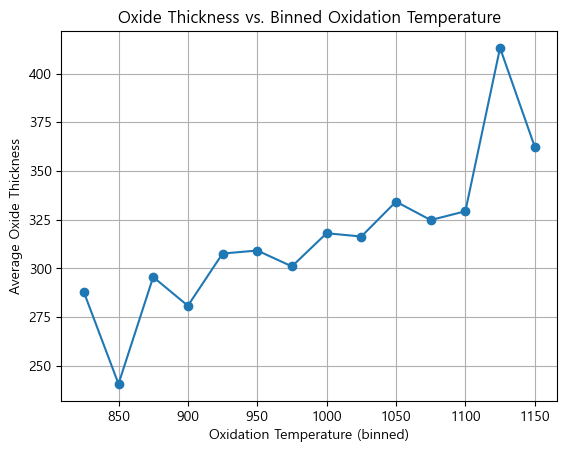

In [7]:
# 온도 구간(예: 25℃)으로 binning
df['temp_bin'] = (df['oxidation_temperature'] // 25) * 25
# bin별 평균 구하기
df_grouped = df.groupby('temp_bin')['oxide_thickness'].mean().reset_index()

import matplotlib.pyplot as plt
plt.plot(df_grouped['temp_bin'], df_grouped['oxide_thickness'], marker='o')
plt.xlabel('Oxidation Temperature (binned)')
plt.ylabel('Average Oxide Thickness')
plt.title('Oxide Thickness vs. Binned Oxidation Temperature')
plt.grid(True)
plt.show()



✅ 분석 결과가 'oxide_thickness_comparison_plot.png' 파일로 시각화되어 저장되었습니다.


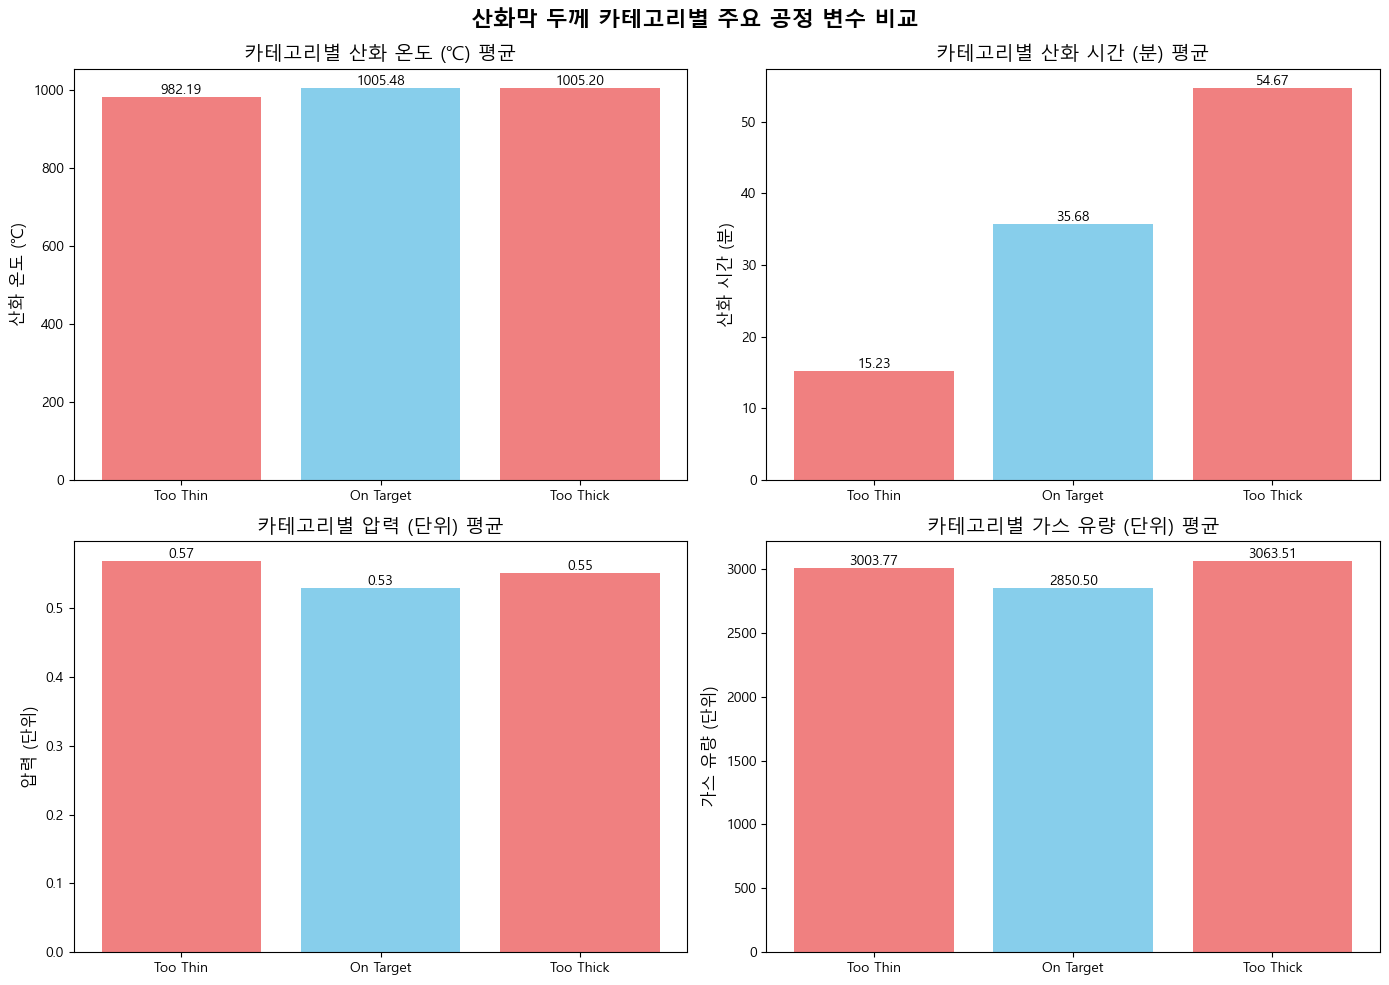

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 변수 설정 및 데이터 로드
file_name = '02_oxide.csv'

# 산화막 두께 분류 기준 정의
TOO_THIN_MAX = 220
TOO_THICK_MIN = 400
ON_TARGET_MIN = 290
ON_TARGET_MAX = 330

# 파일 로드 (직접 로드)
df = pd.read_csv(file_name)

# 2. 데이터 전처리 및 분류 함수 정의
# 분석의 핵심 변수에 결측치가 있는 행을 제거
df_cleaned = df.dropna(subset=['oxide_thickness', 'oxidation_temperature', 'pressure']).copy()

# 산화막 두께를 카테고리로 분류하는 함수
def categorize_thickness(thickness):
    if thickness < TOO_THIN_MAX:
        return 'Too Thin'
    elif thickness > TOO_THICK_MIN:
        return 'Too Thick'
    elif ON_TARGET_MIN <= thickness <= ON_TARGET_MAX:
        return 'On Target'
    else:
        return 'Other'

# 분류 함수 적용하여 새 컬럼 생성
df_cleaned['thickness_category'] = df_cleaned['oxide_thickness'].apply(categorize_thickness)

# 3. 그룹별 공정 변수 평균 비교 분석

# 비교 대상 공정 변수 정의 (두께 제외)
process_vars = [
    'precleaning_time',
    'oxidation_temperature',
    'oxidation_time',
    'pressure',
    'gas_flow_rate'
]

# 비교할 세 가지 카테고리만 필터링
comparison_categories = ['Too Thin', 'Too Thick', 'On Target']
comparison_df = df_cleaned[df_cleaned['thickness_category'].isin(comparison_categories)]

# 카테고리별 공정 변수의 평균 계산
comparison_results = comparison_df.groupby('thickness_category')[process_vars].mean().reset_index()

# 시각화 순서 정의 (Too Thin -> On Target -> Too Thick 순으로 정렬)
order = ['Too Thin', 'On Target', 'Too Thick']
comparison_results['thickness_category'] = pd.Categorical(comparison_results['thickness_category'], categories=order, ordered=True)
comparison_results = comparison_results.sort_values('thickness_category')

# 4. 결과 시각화 (matplotlib)

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 시각화할 주요 4가지 변수 정의 (precleaning_time은 변동 폭이 작아 제외)
plot_vars = [
    'oxidation_temperature',
    'oxidation_time',
    'pressure',
    'gas_flow_rate'
]

# 각 변수별 막대 그래프 생성
for i, var in enumerate(plot_vars):
    ax = axes[i]
    categories = comparison_results['thickness_category']
    values = comparison_results[var]
    
    # 막대 그래프 생성
    ax.bar(categories, values, color=['skyblue' if cat == 'On Target' else 'lightcoral' for cat in categories])
    
    # 평균 두께 값 표시
    for j, val in enumerate(values):
        ax.text(j, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    
    # 축 및 제목 설정
    # 컬럼명을 한국어로 변환하여 제목으로 사용
    korean_labels = {
        'oxidation_temperature': '산화 온도 (℃)',
        'oxidation_time': '산화 시간 (분)',
        'pressure': '압력 (단위)',
        'gas_flow_rate': '가스 유량 (단위)'
    }
    ax.set_title(f'카테고리별 {korean_labels.get(var, var)} 평균', fontsize=14)
    ax.set_ylabel(korean_labels.get(var, var), fontsize=12)
    ax.tick_params(axis='x', rotation=0)

# 레이아웃 조정 및 제목 설정
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle('산화막 두께 카테고리별 주요 공정 변수 비교', fontsize=16, fontweight='bold')

# 이미지 파일로 저장
plt.savefig('oxide_thickness_comparison_plot.png')
print("\n✅ 분석 결과가 'oxide_thickness_comparison_plot.png' 파일로 시각화되어 저장되었습니다.")

C:\Users\sec\AppData\Local\Temp\ipykernel_139376\4161874620.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='thickness_category', y=var, data=comparison_df,
C:\Users\sec\AppData\Local\Temp\ipykernel_139376\4161874620.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='thickness_category', y=var, data=comparison_df,
C:\Users\sec\AppData\Local\Temp\ipykernel_139376\4161874620.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='thickness_category', y=var, data=comparison_df,
C:\Users\sec\AppData\Local\Temp\ipykernel_139376\416187


✅ 분석 결과가 'oxide_thickness_boxplot_comparison.png' 파일로 박스 플롯 시각화되어 저장되었습니다.


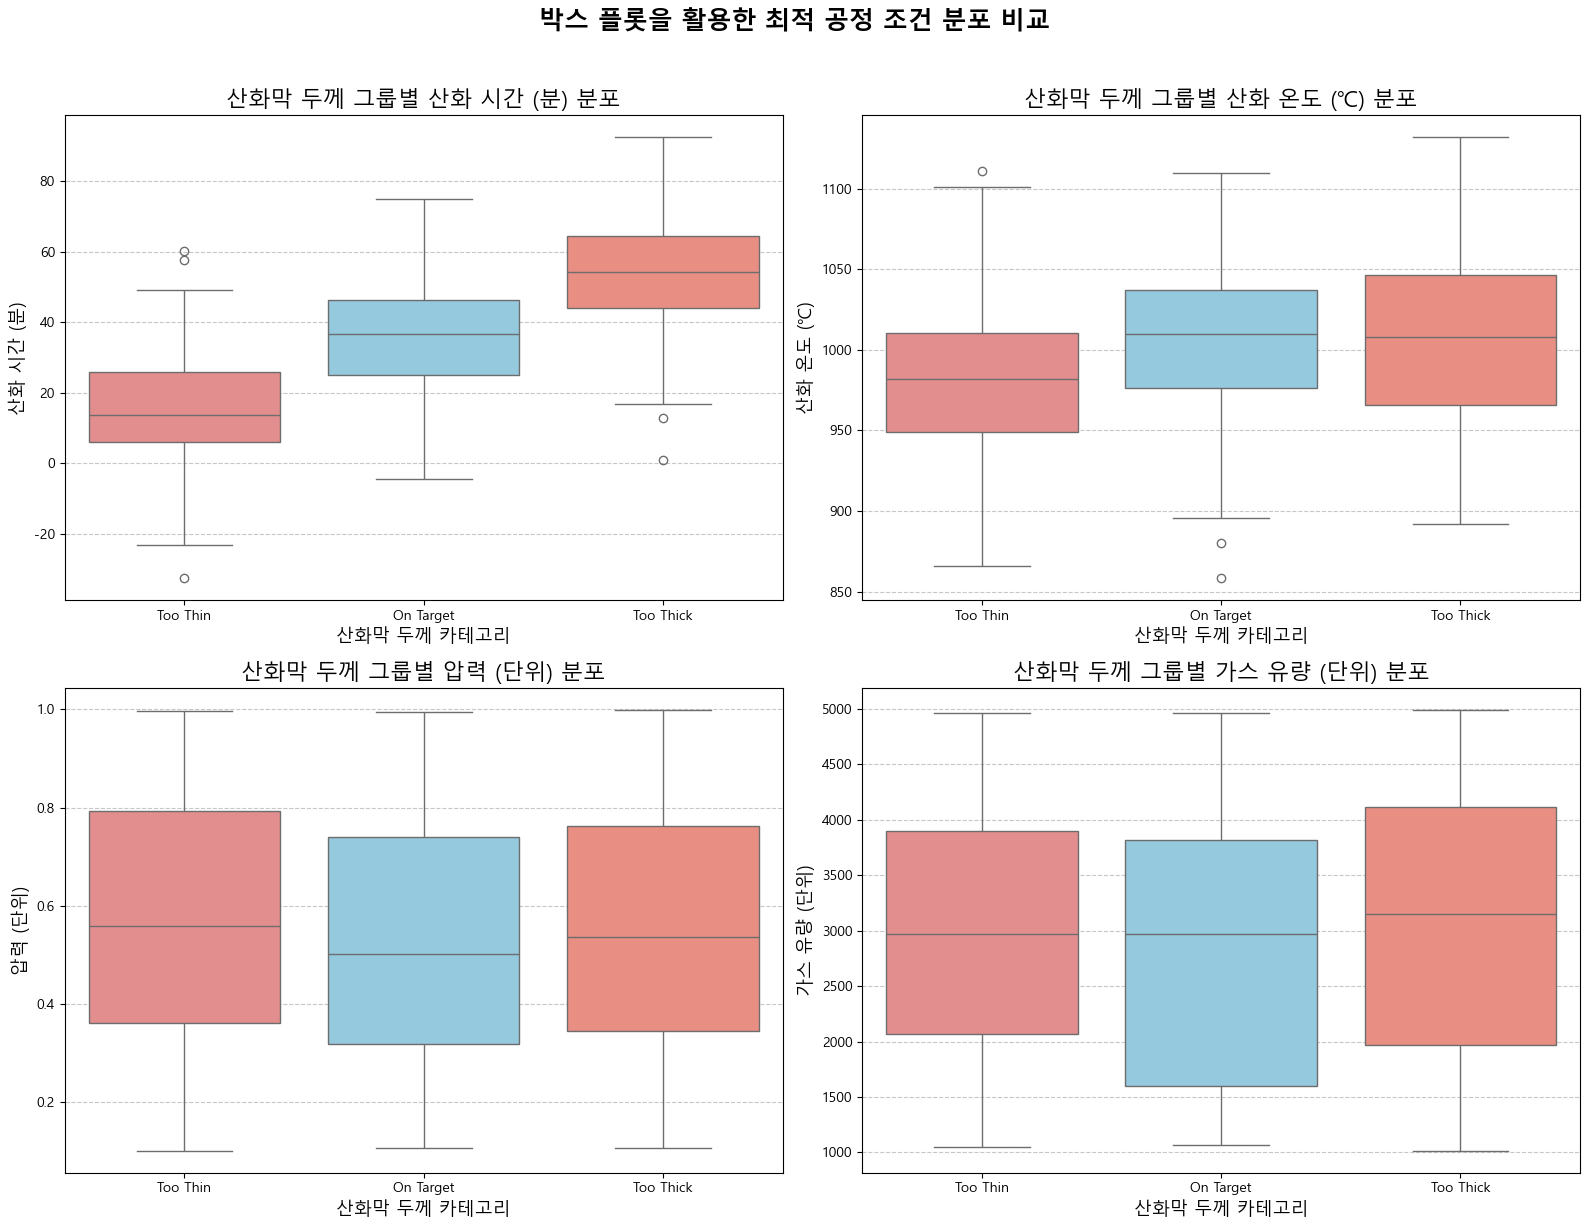

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 변수 설정 및 데이터 로드
file_name = '02_oxide.csv'

# 산화막 두께 분류 기준 정의
TOO_THIN_MAX = 220
TOO_THICK_MIN = 400
ON_TARGET_MIN = 290
ON_TARGET_MAX = 330

# 파일 로드
df = pd.read_csv(file_name)

# 2. 데이터 전처리 및 분류 함수 정의
df_cleaned = df.dropna(subset=['oxide_thickness', 'oxidation_temperature', 'pressure']).copy()

def categorize_thickness(thickness):
    if thickness < TOO_THIN_MAX:
        return 'Too Thin'
    elif thickness > TOO_THICK_MIN:
        return 'Too Thick'
    elif ON_TARGET_MIN <= thickness <= ON_TARGET_MAX:
        return 'On Target'
    else:
        return 'Other'

df_cleaned['thickness_category'] = df_cleaned['oxide_thickness'].apply(categorize_thickness)

# 3. 그룹별 데이터 필터링
comparison_categories = ['Too Thin', 'On Target', 'Too Thick']
comparison_df = df_cleaned[df_cleaned['thickness_category'].isin(comparison_categories)].copy()

# 시각화 순서 정의
order = ['Too Thin', 'On Target', 'Too Thick']
comparison_df['thickness_category'] = pd.Categorical(comparison_df['thickness_category'], categories=order, ordered=True)

# 4. 결과 시각화 (Seaborn Box Plot)

# 시각화할 주요 4가지 변수 정의
plot_vars = [
    'oxidation_time',
    'oxidation_temperature',
    'pressure',
    'gas_flow_rate'
]

# 한국어 라벨 설정
korean_labels = {
    'oxidation_time': '산화 시간 (분)',
    'oxidation_temperature': '산화 온도 (℃)',
    'pressure': '압력 (단위)',
    'gas_flow_rate': '가스 유량 (단위)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    
    # seaborn boxplot 생성
    sns.boxplot(x='thickness_category', y=var, data=comparison_df, 
                order=order, palette={'On Target': 'skyblue', 'Too Thin': 'lightcoral', 'Too Thick': 'salmon'},
                ax=ax)
    
    ax.set_title(f'산화막 두께 그룹별 {korean_labels.get(var)} 분포', fontsize=16)
    ax.set_xlabel('산화막 두께 카테고리', fontsize=13)
    ax.set_ylabel(korean_labels.get(var), fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# 전체 레이아웃 조정 및 제목 설정
plt.suptitle('박스 플롯을 활용한 최적 공정 조건 분포 비교', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

✅ 'uniformity_category' 컬럼 생성 완료.


C:\Users\sec\AppData\Local\Temp\ipykernel_139376\4170083781.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='uniformity_category', y=var, data=comparison_df_filtered,
C:\Users\sec\AppData\Local\Temp\ipykernel_139376\4170083781.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='uniformity_category', y=var, data=comparison_df_filtered,


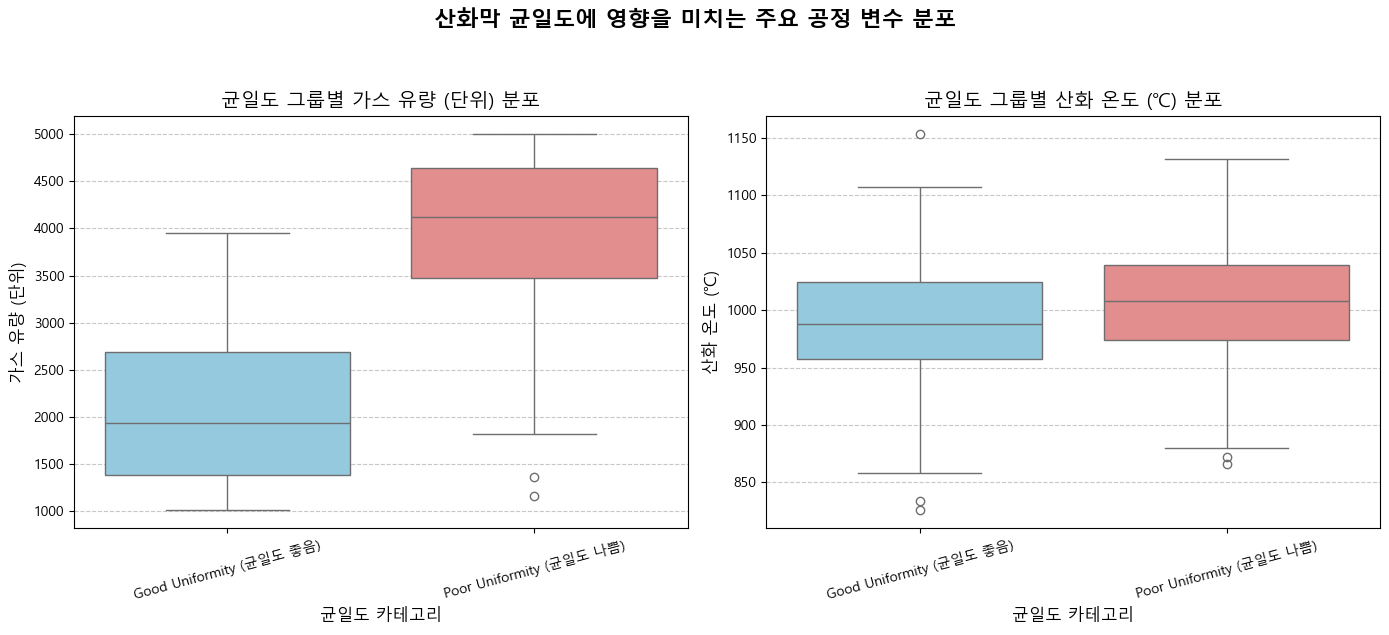

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_name = '02_oxide.csv'
df = pd.read_csv(file_name)

# 1. 데이터 정제 및 균일도 기준 설정
key_cols = ['uniformity', 'oxidation_temperature', 'oxidation_time', 'pressure', 'gas_flow_rate']
df_cleaned = df.dropna(subset=key_cols).copy()

# 균일도 분포 파악 및 그룹 기준 설정 (Q1, Q3)
q1 = df_cleaned['uniformity'].quantile(0.25)
q3 = df_cleaned['uniformity'].quantile(0.75)

# 2. 균일도 카테고리 생성
# 균일도 그룹 분류 함수 (이제 이 함수가 df_cleaned를 만듭니다)
def categorize_uniformity(uni):
    if uni <= q1:
        return 'Good Uniformity (균일도 좋음)'
    elif uni >= q3:
        return 'Poor Uniformity (균일도 나쁨)'
    else:
        return 'Intermediate (중간)'

df_cleaned['uniformity_category'] = df_cleaned['uniformity'].apply(categorize_uniformity)

# 3. 데이터 필터링 및 시각화 준비
plot_vars_uni = [
    'gas_flow_rate',
    'oxidation_temperature'
]
korean_labels_uni = {
    'gas_flow_rate': '가스 유량 (단위)',
    'oxidation_temperature': '산화 온도 (℃)'
}
order_uni = ['Good Uniformity (균일도 좋음)', 'Poor Uniformity (균일도 나쁨)']

comparison_df_filtered = df_cleaned[df_cleaned['uniformity_category'].isin(order_uni)].copy()
comparison_df_filtered['uniformity_category'] = pd.Categorical(
    comparison_df_filtered['uniformity_category'], 
    categories=order_uni, 
    ordered=True
)

# 4. 박스 플롯 시각화 실행 (Seaborn)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, var in enumerate(plot_vars_uni):
    ax = axes[i]
    
    sns.boxplot(x='uniformity_category', y=var, data=comparison_df_filtered, 
                order=order_uni, 
                palette={'Good Uniformity (균일도 좋음)': 'skyblue', 'Poor Uniformity (균일도 나쁨)': 'lightcoral'},
                ax=ax)
    
    ax.set_title(f'균일도 그룹별 {korean_labels_uni.get(var)} 분포', fontsize=14)
    ax.set_xlabel('균일도 카테고리', fontsize=12)
    ax.set_ylabel(korean_labels_uni.get(var), fontsize=12)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('산화막 균일도에 영향을 미치는 주요 공정 변수 분포', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()


In [ ]:
# 2. 'crack' 결함만 필터링
crack_df = df[df['defect_type'] == 'crack']

# 3. chamber_id별 개수 계산 (value_counts() 사용)
# value_counts()는 개수 계산과 정렬을 한 번에 처리합니다.
crack_counts = crack_df['chamber_id'].value_counts()

# 4. 결과를 DataFrame으로 변환하고 컬럼 이름 설정
crack_summary_df = crack_counts.to_frame(name='Crack Defect Count')

# 5. 총 Crack 결함 개수 계산
total_crack_count = crack_summary_df['Crack Defect Count'].sum()

# 6. 퍼센테이지 컬럼 계산 및 소수점 포맷 지정
crack_summary_df['Percentage (%)'] = (crack_summary_df['Crack Defect Count'] / total_crack_count) * 100
crack_summary_df['Percentage (%)'] = crack_summary_df['Percentage (%)'].round(2)


print("--- Chamber 별 Crack 결함 개수 ---")
print(crack_summary_df)


--- Chamber 별 Crack 결함 개수 ---
            Crack Defect Count  Percentage (%)
chamber_id                                    
chamber_1                   49           44.14
chamber_2                   33           29.73
chamber_3                   29           26.13


In [20]:
# 2. 분석 대상 그룹만 필터링: 'crack'과 'none'
comparison_df = df[df['defect_type'].isin(['crack', 'none'])].copy()

# 3. 분석할 수치형 컬럼 정의
# 'precleaning_time'은 discrete하지만 일단 수치형으로 비교합니다.
numeric_cols = ['precleaning_time', 'oxidation_temperature', 'oxidation_time', 'pressure', 'gas_flow_rate', 'oxide_thickness', 'uniformity']

# 4. 'defect_type'별로 그룹화하여 각 컬럼의 평균 계산
means_by_defect = comparison_df.groupby('defect_type')[numeric_cols].mean()

# 5. 결과를 하나의 DataFrame으로 통합
crack_means = means_by_defect.loc['crack']
none_means = means_by_defect.loc['none']

comparison_summary_df = pd.DataFrame({
    'Crack Group Mean': crack_means.round(2),
    'None Group Mean': none_means.round(2),
    'Ratio (Crack / None)': (crack_means / none_means).round(3)
})

# 6. 'Ratio' 기준으로 정렬하여 영향이 큰 순서대로 시각화
# Ratio가 1.0에서 가장 많이 벗어나는 변수가 핵심 요인입니다.
comparison_summary_df = comparison_summary_df.sort_values(by='Ratio (Crack / None)', key=lambda x: abs(x - 1), ascending=False)

print("--- Crack 결함 vs. None 그룹 수치형 공정 변수 비교 (평균) ---")
print(comparison_summary_df)

--- Crack 결함 vs. None 그룹 수치형 공정 변수 비교 (평균) ---
                       Crack Group Mean  None Group Mean  Ratio (Crack / None)
uniformity                         2.38             2.64                 0.904
oxidation_time                    33.05            36.21                 0.913
precleaning_time                   2.88             3.11                 0.927
oxide_thickness                  301.04           315.82                 0.953
gas_flow_rate                   2882.94          3014.13                 0.956
pressure                           0.54             0.55                 0.983
oxidation_temperature           1004.15           998.47                 1.006


In [2]:
import pandas as pd

# 출력 결과가 잘리지 않도록 옵션 설정 (가로로 길게 보기)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# pd.set_option('display.max_rows', None) # 필요시 주석 해제하면 모든 행을 볼 수 있습니다.

def analyze_categories_basic(file_path):
    print(f"--- 분석 시작: {file_path} ---")
    
    # 1. 데이터 로드
    try:
        df = pd.read_csv(file_path)
        print(f"▶ 전체 데이터 개수: {len(df)}개")
    except FileNotFoundError:
        print("오류: 파일을 찾을 수 없습니다.")
        return

    # -------------------------------------------------------
    # [데이터 전처리] 결측치 및 음수 이상치 제거
    # -------------------------------------------------------
    # 결측치 제거
    df_clean = df.dropna()
    
    # 음수 제거 (시간, 온도, 압력, 유량, 두께, 균일도)
    numeric_cols = ['oxidation_time', 'precleaning_time', 'oxidation_temperature', 
                    'pressure', 'gas_flow_rate', 'oxide_thickness', 'uniformity']
    
    for col in numeric_cols:
        # 데이터 타입 안전성을 위해 수치형으로 강제 변환 후 비교
        df_clean = df_clean[pd.to_numeric(df_clean[col], errors='coerce') >= 0]
        
    print(f"▶ 전처리 후 데이터 개수: {len(df_clean)}개 (이상치/결측치 제거 완료)")
    print("-" * 60)

    # -------------------------------------------------------
    # [공통 함수] 그룹별 불량률 계산기
    # -------------------------------------------------------
    def get_crack_stats(data, group_cols):
        # 1. 전체 처리량
        total = data.groupby(group_cols).size()
        
        # 2. Crack 불량 개수
        cracks = data[data['defect_type'] == 'crack'].groupby(group_cols).size()
        
        # 3. 합치기
        stats = pd.DataFrame({'Total Processed': total, 'Crack Count': cracks})
        
        # 4. 결측치(0) 처리
        stats['Crack Count'] = stats['Crack Count'].fillna(0).astype(int)
        
        # 5. 불량률(%) 계산
        stats['Crack Rate (%)'] = (stats['Crack Count'] / stats['Total Processed'] * 100).round(2)
        
        # 6. 불량률 높은 순 정렬
        return stats.sort_values(by='Crack Rate (%)', ascending=False)

    # -------------------------------------------------------
    # [분석 1] 장비(Equipment)별 분석
    # -------------------------------------------------------
    print("\n📊 [분석 1] 장비(Equipment)별 Crack 발생 현황")
    print(get_crack_stats(df_clean, 'equipment_id'))

    # -------------------------------------------------------
    # [분석 2] 챔버(Chamber)별 분석
    # -------------------------------------------------------
    print("\n📊 [분석 2] 챔버(Chamber)별 Crack 발생 현황")
    print(get_crack_stats(df_clean, 'chamber_id'))

    # -------------------------------------------------------
    # [분석 3] 장비+챔버 조합 상세 분석 (가장 중요!)
    # -------------------------------------------------------
    print("\n📊 [분석 3] 장비+챔버 조합별 상세 발생 현황")
    print(get_crack_stats(df_clean, ['equipment_id', 'chamber_id']))

# 함수 실행
analyze_categories_basic("02_oxide.csv")

--- 분석 시작: 02_oxide.csv ---
▶ 전체 데이터 개수: 1000개
▶ 전처리 후 데이터 개수: 949개 (이상치/결측치 제거 완료)
------------------------------------------------------------

📊 [분석 1] 장비(Equipment)별 Crack 발생 현황
              Total Processed  Crack Count  Crack Rate (%)
equipment_id                                              
eq_1                      191           24           12.57
eq_3                      191           22           11.52
eq_2                      192           22           11.46
eq_4                      185           18            9.73
eq_5                      190           18            9.47

📊 [분석 2] 챔버(Chamber)별 Crack 발생 현황
            Total Processed  Crack Count  Crack Rate (%)
chamber_id                                              
chamber_1               324           48           14.81
chamber_2               308           31           10.06
chamber_3               317           25            7.89

📊 [분석 3] 장비+챔버 조합별 상세 발생 현황
                         Total Processed  Crack Count  C